<a href="https://colab.research.google.com/github/Dcarlos-02/DATA201__SP26/blob/main/Logistic_regression_assignment_Carlos_Sidney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week4 assignment Linear regression**

## Importing libraries

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [20]:
import statsmodels.formula.api as smf

# **Loading data**

In [21]:
df = pd.read_csv('https://raw.githubusercontent.com/Dcarlos-02/Data201/main/Dataset/housing.csv')
df

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily
...,...,...,...,...,...,...
595,100596,232811.0,1443.241197,3.0,Midtown,Condo
596,100597,235624.0,1083.909714,2.0,Suburb,Condo
597,100598,244889.0,1600.126432,1.0,Suburb,SingleFamily
598,100599,239545.0,1248.216637,1.0,Waterfront,Condo


In [22]:
df.isna().sum()

,0
listing_id,0
price,0
size,53
bedrooms,24
neighborhood,0
type,0


In [23]:
avg_bed = np.mean(df['bedrooms'])
df['bedrooms'].fillna(np.absolute(avg_bed), inplace=True)

/tmp/ipykernel_759/1199567132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].fillna(np.absolute(avg_bed), inplace=True)


In [24]:
avg_size = np.mean(df['size'])

df['size'].fillna(avg_size, inplace=True)

/tmp/ipykernel_759/2908978215.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size'].fillna(avg_size, inplace=True)


In [25]:
df.isna().sum()

,0
listing_id,0
price,0
size,0
bedrooms,0
neighborhood,0
type,0


## **Creating binary outcome**

In [26]:
median_price = np.median(df['price'])


In [27]:
df['high_price'] = np.where (df['price'] >= median_price, 1, 0)

In [28]:
df.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0


# **Part A  Logistic regression for inference**

In [29]:
model1 = smf.logit('high_price ~ size + bedrooms + C(neighborhood)', data=df).fit()
model1.summary()

Optimization terminated successfully.
         Current function value: 0.686397
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             high_price   No. Observations:                  600
Model:                          Logit   Df Residuals:                      593
Method:                           MLE   Df Model:                            6
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                0.009739
Time:                        12:16:21   Log-Likelihood:                -411.84
converged:                       True   LL-Null:                       -415.89
Covariance Type:            nonrobust   LLR p-value:                    0.2308
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3519      0.274      1.285      0.199      -0.185       0.889
C(neighborhood)[T.Midtown]       -0.2987      0.262     -1.140      0.254      -0.812       0.215
C(neighborhood)[T.Suburb]         0.0754      0.237      0.317      0.751      -0.390       0.541
C(neighborhood)[T.Uptown]         0.0335      0.258      0.130      0.897      -0.472       0.539
C(neighborhood)[T.Waterfront]     0.4291      0.333      1.290      0.197      -0.223       1.081
size                             -0.0004      0.000     -1.762      0.078      -0.001    4.34e-05
bedrooms                          0.1409      0.114      1.238      0.216      -0.082       0.364
=================================================================================================
"""

In [30]:
model1.params

,0
Intercept,0.351857
C(neighborhood)[T.Midtown],-0.298660
C(neighborhood)[T.Suburb],0.075394
C(neighborhood)[T.Uptown],0.033544
C(neighborhood)[T.Waterfront],0.429121
size,-0.000386
bedrooms,0.140949


In [31]:
odd_ratio = np.exp(model1.params)
odd_ratio


,0
Intercept,1.421705
C(neighborhood)[T.Midtown],0.741812
C(neighborhood)[T.Suburb],1.078309
C(neighborhood)[T.Uptown],1.034113
C(neighborhood)[T.Waterfront],1.535907
size,0.999614
bedrooms,1.151366


Coefficient | Odd Ratio | P-value | feature
------------|-----------|-----------|---------
 0.351857 | 1.421705 | 0.199 | intercept
 -0.298660 | 0.741812 | 0.254 | C(neighborhood)[Midtown]
 0.075394 | 1.078309 | 0.751 | C(neighborhood)[Suburb]
 0.033544 | 1.034113 | 0.897 | C(neighborhood)[Uptown]
 0.0429121| 1.535907 | 0.197 | C(neighborhood)[Waterfront]
 -0.000386 | 0.999614 | 0.078 | size
 0.140949 | 1.151366 | 0.216 | bedrooms

* Considering the metrics above, none of the predictors are statisticatically significant because the returned p-values that are higher than the standard 0.05 threshold. Moreover, the coefficients support this statement. Although the majority of the coefficients are positive, they contribute poorly into increasing the price of house.

* The neighborhood that has the highest odds of expensive home is the "Waterfront" category with an odds ratio of 1.535907.


# **Part B: Interpretation**

The size of a house slightly impacts its final price. Here, the feature "size" has an odd ratio of 0.999614, which means that for each addtional square foot, a house expensiveness is likely to increase by 0.999614. However, the log odds do not play in favor of that event. The model returned a coefficient od -0.000386, meaning that as the size increases, the house being expensive is less likely to be true. Since these numbers are low, there will not be significant impact.

# **Part C: Prediction workflow**

In [32]:
if 'neighborhood' in df.columns:
    df = pd.get_dummies(df, columns=["neighborhood"], drop_first=True)

In [42]:
#building the model

model2 = LogisticRegression()

In [45]:
#splitting the data
X = df.drop(columns=['listing_id', 'price', 'type', 'high_price'])
y = df['high_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
#fitting the model

model2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
y_pred = model2.predict(X_test)

In [48]:
y_probz = model2.predict_proba(X_test)

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [49]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.4083333333333333

In [50]:
roc_auc = roc_auc_score(y_test, y_probz[:,1])
roc_auc


np.float64(0.4466722361459204)

Text(0.5, 1.0, 'ROC_AUC Curve')

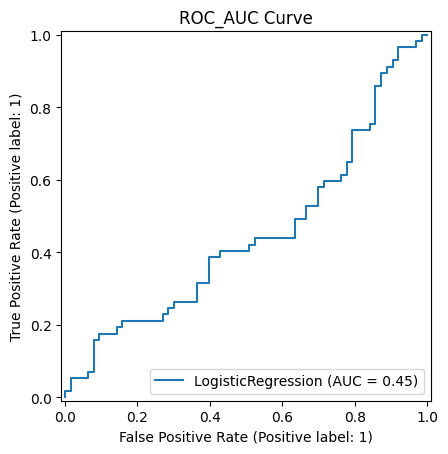

In [51]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model2, X_test, y_test)

plt.title('ROC_AUC Curve')

# **Part D - Model understanding**

Roc-AUC might sometimes be preferred over accuracy because ROC_AUC tells about the model's ability to distinguish between the outcomes. Also, it does not depend on one threshold to classify the outcomes. It evaluates the outcomes regarding all possible thresholds, giving a more realistic picture.

Although both approaches are strong, they provides specific advantages. For policy analysis, I would choose statsmodel because it provides rich statistical outputs such as p-values, standard error, and confidence interval that allows the understanding of relationships between variables. However, for a task that is centered around forecasting, Sklearn is more suitable. It provides a vast collection of algorithm that facilitates the evaluation of a model performance, making it more relevant for building robust predictive systems.

# **Part E- EDA**

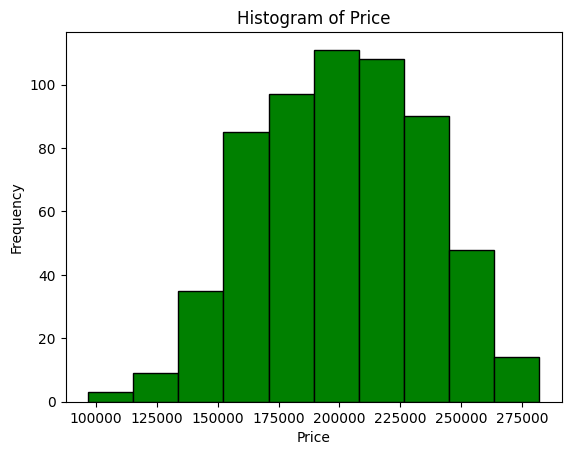

In [56]:
#creating a histogram of price

plt.hist(df['price'], bins=10, color='green', edgecolor='black')
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

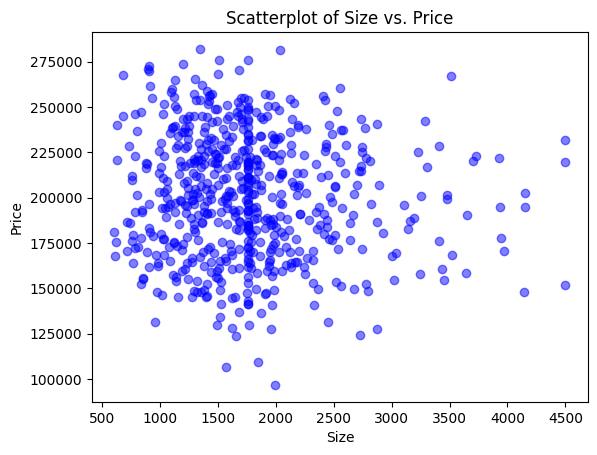

In [58]:
#creating a scatterplot

plt.scatter(df['size'], df['price'], color='blue', alpha=0.5)
plt.title('Scatterplot of Size vs. Price')
plt.xlabel('Size')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_759/83678309.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_original['bedrooms'].fillna(np.absolute(avg_bed_original), inplace=True)
/tmp/ipykernel_759/83678309.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

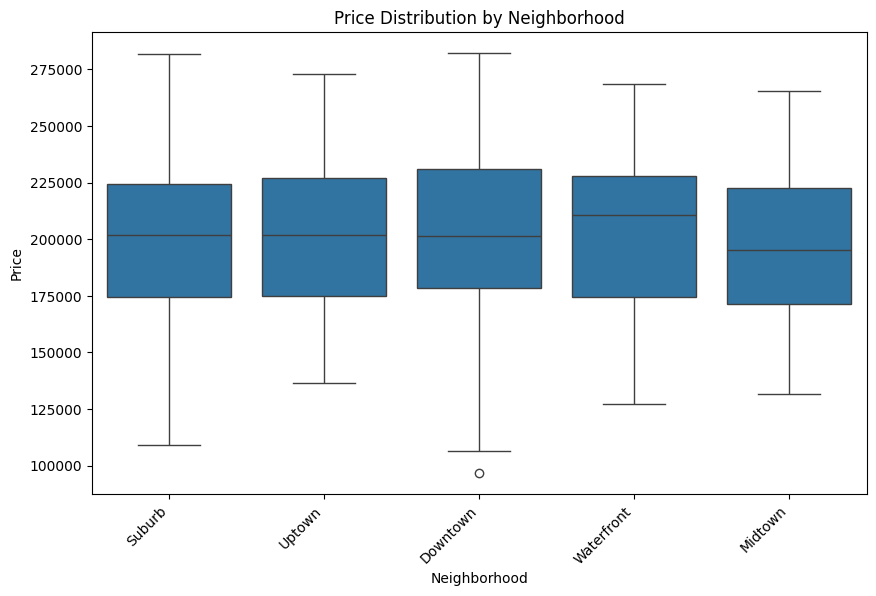

In [62]:
import seaborn as sns

# Reload the original DataFrame to get the 'neighborhood' column back for plotting
df_original = pd.read_csv('https://raw.githubusercontent.com/Dcarlos-02/Data201/main/Dataset/housing.csv')

# Fill NaN values for 'bedrooms' and 'size' as done previously
avg_bed_original = np.mean(df_original['bedrooms'])
df_original['bedrooms'].fillna(np.absolute(avg_bed_original), inplace=True)
avg_size_original = np.mean(df_original['size'])
df_original['size'].fillna(avg_size_original, inplace=True)


plt.figure(figsize=(10, 6))
sns.boxplot(x='neighborhood', y='price', data=df_original)
plt.title('Price Distribution by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='type', ylabel='count'>

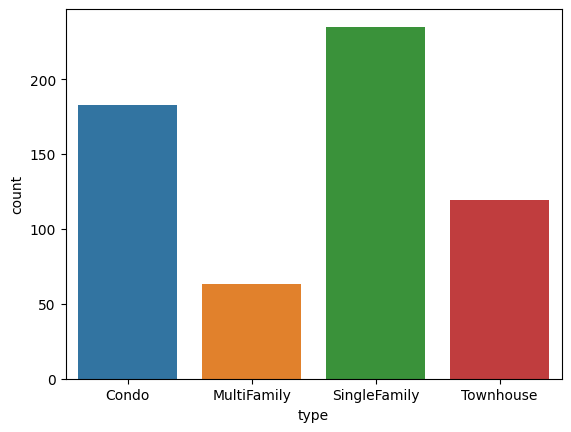

In [65]:
#creating a bar chart of house type

type_counts = df.groupby('type')['type'].value_counts().reset_index()

sns.barplot(x='type', y='count', hue='type', data=type_counts)
